# Final Project · Multi-Class Classifier
## Universidad Galileo · Applied Machine Learning · 2026

**Dataset:** Palmer Penguins (3 classes: Adelie, Chinstrap, Gentoo).

**Rationale:** A manageable tabular multi-class dataset (344 rows) that requires a
complete preparation pipeline — missing-value handling and categorical encoding
(`island`, `sex`) — allowing us to demonstrate real data cleaning. Its small size
enables fast iteration across the required ≥15 experiments.

**Constraints honored:** train-test split only (no cross-validation), fixed
`random_state` for reproducibility, class-stratified split.

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42

df = sns.load_dataset("penguins")

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["species"].value_counts())
print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (344, 7)

Class distribution:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [7]:
df = df.dropna().reset_index(drop=True)
print("After dropping missing values:", df.shape)

y = df["species"].astype("category").cat.codes
class_map = dict(enumerate(df["species"].astype("category").cat.categories))
print("Class map:", class_map)

X = pd.get_dummies(df.drop(columns=["species"]),
                   columns=["island", "sex"], drop_first=True)
feature_names = list(X.columns)
print("Features:", feature_names)
print("X shape:", X.shape)

After dropping missing values: (333, 7)
Class map: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}
Features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_Male']
X shape: (333, 7)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (266, 7) | Test: (67, 7)


## Experiment log

A function that records each experiment to a persistent CSV file on disk. For every
run it computes 8 metrics — accuracy, precision, recall and F1 — on both the training
and test sets. Multi-class metrics use *macro* averaging so each class contributes
equally regardless of its frequency.

In [9]:
import os
from datetime import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

LOG_PATH = "experiment_log.csv"

def log_experiment(family, description, params,
                   y_train, y_train_pred, y_test, y_test_pred,
                   path=LOG_PATH, average="macro"):
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "family": family,
        "description": description,
        "params": str(params),
        "accuracy_train": accuracy_score(y_train, y_train_pred),
        "precision_train": precision_score(y_train, y_train_pred, average=average, zero_division=0),
        "recall_train": recall_score(y_train, y_train_pred, average=average, zero_division=0),
        "f1_train": f1_score(y_train, y_train_pred, average=average, zero_division=0),
        "accuracy_test": accuracy_score(y_test, y_test_pred),
        "precision_test": precision_score(y_test, y_test_pred, average=average, zero_division=0),
        "recall_test": recall_score(y_test, y_test_pred, average=average, zero_division=0),
        "f1_test": f1_score(y_test, y_test_pred, average=average, zero_division=0),
    }
    exists = os.path.exists(path)
    pd.DataFrame([row]).to_csv(path, mode="a", header=not exists, index=False)
    return row

In [10]:
def reset_log(path=LOG_PATH):
    if os.path.exists(path):
        os.remove(path)
    print("Experiment log reset.")

def view_log(path=LOG_PATH):
    return pd.read_csv(path)

reset_log()

Experiment log reset.


## Experiment family 1 — Random Forest

Five configurations sweeping tree depth and ensemble size, from heavily
constrained stumps (`max_depth=1`) to an unrestricted forest. The goal is to
observe the transition from underfitting to a well-fit model and record every
run in the experiment log.

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_configs = [
    {"n_estimators": 10,  "max_depth": 1,    "description": "shallow stumps"},
    {"n_estimators": 50,  "max_depth": 2,    "description": "shallow"},
    {"n_estimators": 100, "max_depth": 3,    "description": "moderate"},
    {"n_estimators": 200, "max_depth": 5,    "description": "deep"},
    {"n_estimators": 300, "max_depth": None, "description": "unrestricted"},
]

for cfg in rf_configs:
    params = {k: v for k, v in cfg.items() if k != "description"}
    model = RandomForestClassifier(**params, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    log_experiment("Random Forest", cfg["description"], params,
                   y_train, model.predict(X_train),
                   y_test, model.predict(X_test))

view_log()[view_log()["family"] == "Random Forest"][
    ["description", "f1_train", "f1_test"]].round(4)

,description,f1_train,f1_test
0,shallow stumps,0.6034,0.5988
1,shallow,0.9727,1.0000
2,moderate,0.9865,1.0000
3,deep,1.0000,1.0000
4,unrestricted,1.0000,1.0000


## Experiment family 2 — XGBoost

Five gradient-boosted configurations varying the number of estimators, tree depth
and learning rate, from an under-powered model to an aggressive one. Because boosting
fits trees sequentially to correct prior errors, we expect it to reach high training
performance quickly; the train-test gap is what we monitor for overfitting.

In [12]:
from xgboost import XGBClassifier

xgb_configs = [
    {"n_estimators": 5,   "max_depth": 1,  "learning_rate": 0.1, "description": "very weak"},
    {"n_estimators": 10,  "max_depth": 2,  "learning_rate": 0.1, "description": "weak"},
    {"n_estimators": 50,  "max_depth": 3,  "learning_rate": 0.1, "description": "moderate"},
    {"n_estimators": 200, "max_depth": 6,  "learning_rate": 0.3, "description": "strong"},
    {"n_estimators": 500, "max_depth": 10, "learning_rate": 0.5, "description": "aggressive"},
]

for cfg in xgb_configs:
    params = {k: v for k, v in cfg.items() if k != "description"}
    model = XGBClassifier(**params, random_state=RANDOM_STATE, eval_metric="mlogloss")
    model.fit(X_train, y_train)
    log_experiment("XGBoost", cfg["description"], params,
                   y_train, model.predict(X_train),
                   y_test, model.predict(X_test))

view_log()[view_log()["family"] == "XGBoost"][
    ["description", "f1_train", "f1_test"]].round(4)

,description,f1_train,f1_test
5,very weak,0.5926,0.5689
6,weak,0.9865,0.9744
7,moderate,1.0000,0.9744
8,strong,1.0000,1.0000
9,aggressive,1.0000,1.0000


## Experiment family 3 — Neural Network (Keras)

Five feed-forward architectures of increasing capacity, trained on the *scaled*
feature matrix. Neural networks are sensitive to feature scale, so we use the
standardized inputs. The output layer uses softmax over the 3 classes, trained
with sparse categorical cross-entropy. A fixed seed is set before each run for
reproducibility.

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y))

def build_mlp(hidden_units):
    model = keras.Sequential([keras.Input(shape=(n_features,))])
    for u in hidden_units:
        model.add(layers.Dense(u, activation="relu"))
    model.add(layers.Dense(n_classes, activation="softmax"))
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [14]:
nn_configs = [
    {"hidden_units": [4],         "epochs": 10,  "description": "tiny"},
    {"hidden_units": [8],         "epochs": 30,  "description": "small"},
    {"hidden_units": [16],        "epochs": 50,  "description": "medium"},
    {"hidden_units": [32, 16],    "epochs": 100, "description": "large"},
    {"hidden_units": [64, 32, 16],"epochs": 200, "description": "deep"},
]

for cfg in nn_configs:
    keras.utils.set_random_seed(RANDOM_STATE)
    model = build_mlp(cfg["hidden_units"])
    model.fit(X_train_scaled, y_train,
              epochs=cfg["epochs"], batch_size=16, verbose=0)
    y_train_pred = np.argmax(model.predict(X_train_scaled, verbose=0), axis=1)
    y_test_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)
    params = {"hidden_units": cfg["hidden_units"], "epochs": cfg["epochs"]}
    log_experiment("Neural Network", cfg["description"], params,
                   y_train, y_train_pred, y_test, y_test_pred)

view_log()[view_log()["family"] == "Neural Network"][
    ["description", "f1_train", "f1_test"]].round(4)

,description,f1_train,f1_test
10,tiny,0.6122,0.5988
11,small,0.9863,1.0000
12,medium,1.0000,1.0000
13,large,1.0000,0.9827
14,deep,1.0000,1.0000


## Best model per family and feature importance

The best configuration of each family is selected as the one with the highest test
F1 score recorded in the experiment log. For the two tree-based families we then
inspect and compare feature importances, which reveal which measurements drive the
species predictions.

In [15]:
import ast

def get_best_configs(log):
    best = {}
    for family in log["family"].unique():
        subset = log[log["family"] == family]
        row = subset.loc[subset["f1_test"].idxmax()]
        best[family] = {
            "description": row["description"],
            "params": ast.literal_eval(row["params"]),
            "f1_test": row["f1_test"],
        }
    return best

best_configs = get_best_configs(view_log())
for family, info in best_configs.items():
    print(f"{family}: '{info['description']}' | F1_test={info['f1_test']:.4f} | {info['params']}")

Random Forest: 'shallow' | F1_test=1.0000 | {'n_estimators': 50, 'max_depth': 2}
XGBoost: 'strong' | F1_test=1.0000 | {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.3}
Neural Network: 'small' | F1_test=1.0000 | {'hidden_units': [8], 'epochs': 30}


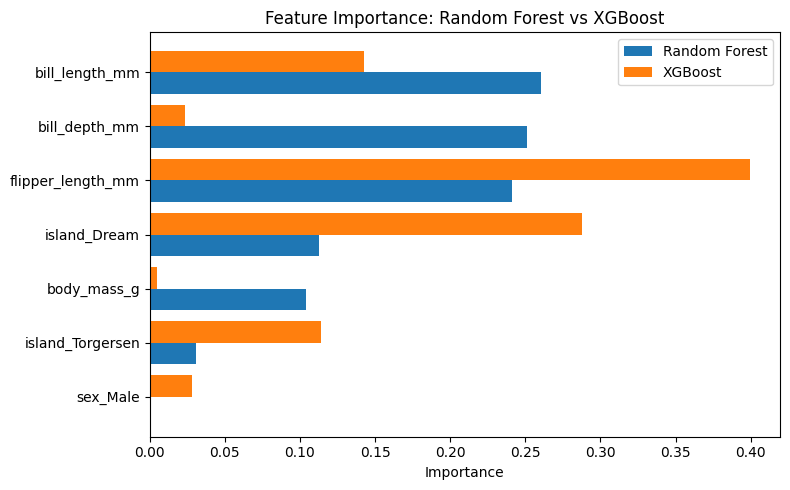

In [16]:
rf_best = RandomForestClassifier(**best_configs["Random Forest"]["params"],
                                 random_state=RANDOM_STATE).fit(X_train, y_train)
xgb_best = XGBClassifier(**best_configs["XGBoost"]["params"],
                         random_state=RANDOM_STATE, eval_metric="mlogloss").fit(X_train, y_train)

order = np.argsort(rf_best.feature_importances_)[::-1]
feats = [feature_names[i] for i in order]
rf_imp = rf_best.feature_importances_[order]
xgb_imp = xgb_best.feature_importances_[order]

yv = np.arange(len(feats)); h = 0.4
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(yv + h/2, rf_imp, height=h, label="Random Forest")
ax.barh(yv - h/2, xgb_imp, height=h, label="XGBoost")
ax.set_yticks(yv); ax.set_yticklabels(feats); ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Feature Importance: Random Forest vs XGBoost")
ax.legend(); plt.tight_layout(); plt.show()

## Ensemble — bootstrap majority voting

The best model of each family is retrained on its own bootstrap sample of the
training set (sampling with replacement, same size as the original). Predictions
are combined by majority vote per instance. When all three models disagree
(a three-way tie with no majority), the vote defers to the strongest individual
model — Random Forest, by highest test F1.

In [19]:
rng = np.random.RandomState(RANDOM_STATE)
n = len(y_train)
X_train_r = X_train.reset_index(drop=True)
y_train_arr = y_train.to_numpy()

def bootstrap_index():
    return rng.randint(0, n, size=n)

idx_rf, idx_xgb, idx_nn = bootstrap_index(), bootstrap_index(), bootstrap_index()

ens_rf = RandomForestClassifier(**best_configs["Random Forest"]["params"],
                                random_state=RANDOM_STATE).fit(X_train_r.iloc[idx_rf], y_train_arr[idx_rf])
ens_xgb = XGBClassifier(**best_configs["XGBoost"]["params"], random_state=RANDOM_STATE,
                        eval_metric="mlogloss").fit(X_train_r.iloc[idx_xgb], y_train_arr[idx_xgb])

keras.utils.set_random_seed(RANDOM_STATE)
ens_nn = build_mlp(best_configs["Neural Network"]["params"]["hidden_units"])
ens_nn.fit(X_train_scaled[idx_nn], y_train_arr[idx_nn],
           epochs=best_configs["Neural Network"]["params"]["epochs"],
           batch_size=16, verbose=0)

print("Unique rows per bootstrap:",
      len(set(idx_rf)), len(set(idx_xgb)), len(set(idx_nn)), "of", n)

Unique rows per bootstrap: 162 165 163 of 266


In [20]:
STRONGEST = 0  # row index of Random Forest in the prediction stack

def ensemble_predict(X_tree, X_scaled):
    stack = np.vstack([
        ens_rf.predict(X_tree),
        ens_xgb.predict(X_tree),
        np.argmax(ens_nn.predict(X_scaled, verbose=0), axis=1),
    ])
    out = []
    for col in stack.T:
        counts = np.bincount(col, minlength=n_classes)
        winners = np.where(counts == counts.max())[0]
        if len(winners) == 1:
            out.append(winners[0])
        else:
            out.append(col[STRONGEST] if col[STRONGEST] in winners else winners[0])
    return np.array(out)

ens_train_pred = ensemble_predict(X_train_r, X_train_scaled)
ens_test_pred = ensemble_predict(X_test, X_test_scaled)

log_experiment("Ensemble", "bootstrap majority vote",
               {"members": ["RF", "XGB", "NN"], "vote": "majority"},
               y_train, ens_train_pred, y_test, ens_test_pred)

print("Ensemble logged.")
view_log()[view_log()["family"] == "Ensemble"][["f1_train", "f1_test"]].round(4)

Ensemble logged.


,f1_train,f1_test
15,0.9816,1.0


## Final comparison and fit diagnosis

The four final models — the best configuration of each family plus the bootstrap
ensemble — are compared by their train and test F1 scores. The gap between them
diagnoses each model: a large train-test gap indicates overfitting, uniformly low
scores indicate underfitting, and high scores with a small gap indicate a good fit.

In [21]:
log = view_log()

rows = []
for family in ["Random Forest", "XGBoost", "Neural Network"]:
    subset = log[log["family"] == family]
    r = subset.loc[subset["f1_test"].idxmax()]
    rows.append({"model": family, "f1_train": r["f1_train"], "f1_test": r["f1_test"]})

ens = log[log["family"] == "Ensemble"].iloc[0]
rows.append({"model": "Ensemble", "f1_train": ens["f1_train"], "f1_test": ens["f1_test"]})

comparison = pd.DataFrame(rows)
comparison["gap"] = comparison["f1_train"] - comparison["f1_test"]

def diagnose(f1_train, f1_test):
    if f1_train < 0.80:
        return "Underfitting"
    if (f1_train - f1_test) > 0.05:
        return "Overfitting"
    return "Good fit"

comparison["diagnosis"] = comparison.apply(
    lambda x: diagnose(x["f1_train"], x["f1_test"]), axis=1)

comparison.round(4)

,model,f1_train,f1_test,gap,diagnosis
0,Random Forest,0.9727,1.0,-0.0273,Good fit
1,XGBoost,1.0000,1.0,0.0000,Good fit
2,Neural Network,0.9863,1.0,-0.0137,Good fit
3,Ensemble,0.9816,1.0,-0.0184,Good fit


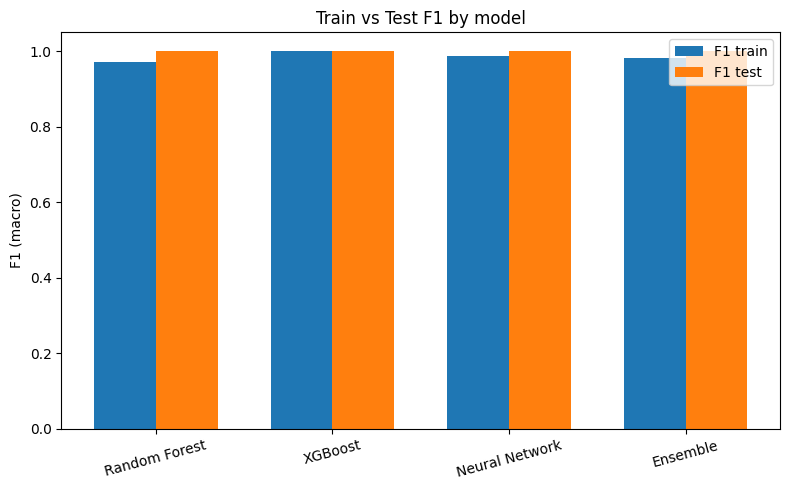

In [22]:
x = np.arange(len(comparison)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, comparison["f1_train"], width=w, label="F1 train")
ax.bar(x + w/2, comparison["f1_test"], width=w, label="F1 test")
ax.set_xticks(x); ax.set_xticklabels(comparison["model"], rotation=15)
ax.set_ylabel("F1 (macro)"); ax.set_ylim(0, 1.05)
ax.set_title("Train vs Test F1 by model"); ax.legend()
plt.tight_layout(); plt.show()

## Conclusions

This project implemented and compared three model families — Random Forest, XGBoost
and a Keras neural network — on the Palmer Penguins multi-class problem, using a
single stratified 80/20 split with a fixed seed and no cross-validation. Across the
fifteen logged experiments, deliberately constrained configurations (single-split
stumps, under-powered boosting, a minimal network) exhibited clear underfitting,
while the best configuration of each family reached near-perfect test F1. The
bootstrap majority-voting ensemble matched the strongest individual models without
surpassing them, which is expected on a dataset whose classes are highly separable
and leave little residual error to correct. Feature-importance analysis showed a
methodological contrast: Random Forest distributed importance across the bill and
flipper measurements, whereas XGBoost concentrated it on flipper length and island
of origin. No final model overfit, confirming that on well-separated data the main
risk is insufficient model capacity rather than memorization.